# TME Music Data Analysis Pipeline
This notebook imports modularized functions from `pipeline`, `reporting`, and `plotting` to perform ETL, analysis, and report generation.

In [1]:
%load_ext autoreload
%autoreload 2

In [19]:
import pandas as pd
from config import (
    BASE_PATH, 
    TOP_N_SONGS, 
    TOP_N_ALBUMS, 
    OUTPUT_SONG_REPORT_PATH, 
    OUTPUT_ALBUM_REPORT_PATH,
    OUTPUT_SONG_REPORT_PATH_MONTHLY
)
from pipeline import run_etl_pipeline, clean_and_unify_data
from reporting import generate_song_report, generate_album_report, generate_song_report_by_year
import plotting

In [20]:
print(BASE_PATH, '\n', OUTPUT_SONG_REPORT_PATH)

/Users/chu-chun/Mirror/Eva/input/sony_TME/大曲庫/ 
 ../output/TME_Song_Report_for_Sony_大曲库.xlsx


## 1. Run ETL Pipeline
Extract data from all raw TME Excel files, calculate platform-specific click metrics, and clean the dataset.

In [21]:
# Run the ETL pipeline to ingest files
df_raw = run_etl_pipeline(BASE_PATH)

# Clean dates, unify platforms, and standardize metadata names
df_cleaned = clean_and_unify_data(df_raw)
df_cleaned.info()

/opt/anaconda3/envs/uda/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/envs/uda/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/envs/uda/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/envs/uda/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/envs/uda/lib/python3.10/site-packages/openpyxl/styles

<class 'pandas.core.frame.DataFrame'>
Index: 2621973 entries, 2143259 to 332577
Data columns (total 12 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Platform         object 
 1   YearMonth        object 
 2   Album            object 
 3   Song             object 
 4   Artist           object 
 5   UPC              object 
 6   ISRC             object 
 7   Revenue          float64
 8   Total_Clicks     float64
 9   source_file      object 
 10  standard_song    object 
 11  standard_artist  object 
dtypes: float64(2), object(10)
memory usage: 260.1+ MB


In [22]:
df_cleaned.head()

,Platform,YearMonth,Album,Song,Artist,UPC,ISRC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
2143259,Wesing,2023-01,挚爱,冷风过境,5566,NaN,TWA770300194,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,冷风过境,5566
2138657,KugouKaraoke,2023-01,空,跳支舞吧,彭文江,NaN,跳支舞吧 - 彭文江,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,跳支舞吧,彭文江
2138658,KugouKaraoke,2023-01,空,复杂情节,彭文江,NaN,复杂情节 - 彭文江,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,复杂情节,彭文江
2138659,KugouKaraoke,2023-01,空,晴天雨天,彭文江,NaN,晴天雨天 - 彭文江,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,晴天雨天,彭文江
2138660,KugouKaraoke,2023-01,空,包围我,彭文江,NaN,包围我 - 彭文江,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,包围我,彭文江


## Monthly Revenue Trend
Plot total monthly revenue and show MoM Growth Percentage.

Monthly Revenue and Clicks Summary:


,YearMonth,revenue,clicks,MoM_Growth_Pct
0,2023-01,8.217495e+05,2.134098e+08,N/A
1,2023-02,8.353066e+05,2.100143e+08,1.65%
2,2023-03,8.930591e+05,2.660883e+08,6.91%
3,2023-04,1.021303e+06,2.921360e+08,14.36%
4,2023-05,1.118740e+06,3.381968e+08,9.54%
5,2023-06,1.009977e+06,2.790816e+08,-9.72%
6,2023-07,9.319006e+05,2.763227e+08,-7.73%
7,2023-08,9.116640e+05,2.638736e+08,-2.17%
8,2023-09,9.442116e+05,2.613260e+08,3.57%
9,2023-10,9.292979e+05,2.701065e+08,-1.58%


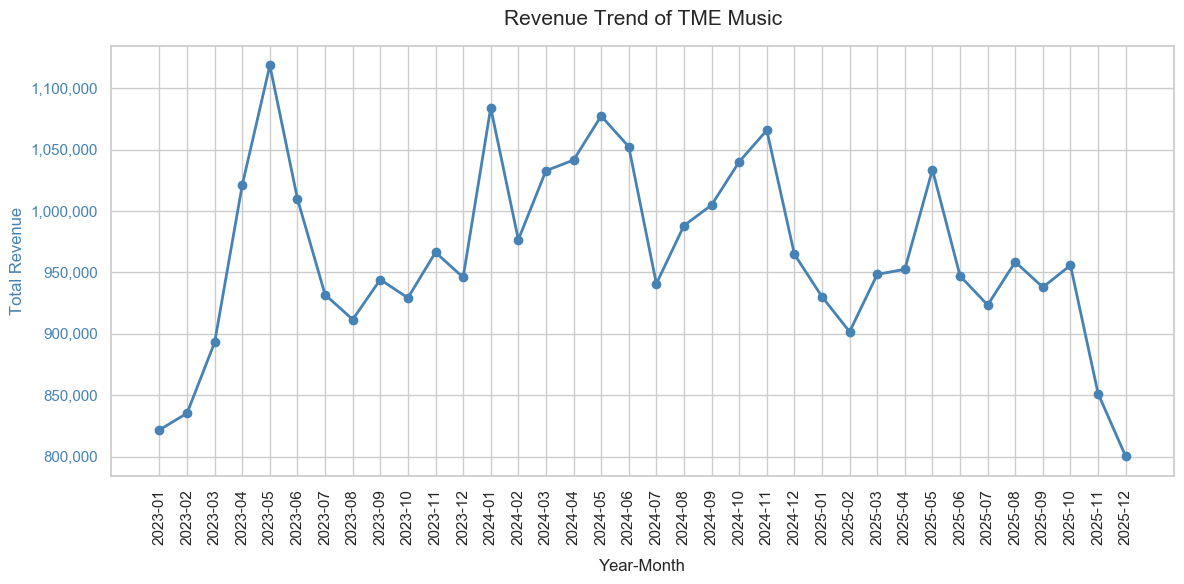

In [23]:
revenue_by_month = (
    df_cleaned.groupby('YearMonth')
    .agg(revenue=('Revenue', 'sum'), clicks=('Total_Clicks', 'sum'))
    .reset_index()
)
revenue_by_month['MoM_Growth_Pct'] = (
    revenue_by_month['revenue']
    .pct_change()
    .apply(lambda x: f"{x:.2%}" if pd.notnull(x) else "N/A")
)

print("Monthly Revenue and Clicks Summary:")
display(revenue_by_month)

# Plot revenue trend line graph
plotting.plot_revenue_trend(revenue_by_month)

## Filter for Specific Analysis Period
Filter the dataset for the designated target period (e.g. 2024-01 to 2026-03).

In [24]:
START_MONTH = "2023-01"
END_MONTH = "2026-06"

df_filtered = df_cleaned[
    (df_cleaned['YearMonth'] >= START_MONTH) & 
    (df_cleaned['YearMonth'] <= END_MONTH)
]
print(f"Filtered dataset from {START_MONTH} to {END_MONTH} contains {len(df_filtered)} rows.")

Filtered dataset from 2023-01 to 2026-06 contains 2621973 rows.


## Top Songs Share & Pie Charts

In [25]:
revenue_by_song = (
    df_filtered
    .groupby(['UPC', 'ISRC'])
    .agg(
        song=('standard_song', 'first'),
        artist=('standard_artist', 'first'),
        revenue=('Revenue', 'sum'),
        clicks=('Total_Clicks', 'sum')
    )
    .reset_index()
)
revenue_by_song = revenue_by_song.sort_values('revenue', ascending=False)

Top 10 songs contribute to 81.81% of total revenue.


,UPC,ISRC,song,artist,revenue,clicks,rev_share,click_share
1098,UPC-828767536125,TWC230515112,恶作剧,王蓝茵,4.162906e+06,948810625.0,0.435435,0.458683
1091,UPC-828767536125,TWC230515103,遇到,方雅贤,1.181709e+06,255544347.0,0.123605,0.123538
284,UPC-4710635380335,TWC230107211,屋顶,"温岚,周杰伦",6.526231e+05,143386080.0,0.068264,0.069317
565,UPC-4712505300245,TWI431603105,漂洋过海来看你,刘明湘,4.512946e+05,59986962.0,0.047205,0.028999
1071,UPC-828767296425,TWC230514205,牡丹江,南拳妈妈,4.310230e+05,89964991.0,0.045085,0.043492
1073,UPC-828767296425,TWC230514207,橘子汽水,南拳妈妈,2.572469e+05,56459568.0,0.026908,0.027294
1057,UPC-8287661891242,TWC230414102,香草吧噗,南拳妈妈,2.184544e+05,46923271.0,0.022850,0.022684
1095,UPC-828767536125,TWC230515107,靠近一点点,Lara梁心颐,1.773496e+05,37844824.0,0.018551,0.018295
1090,UPC-828767536125,TWC230515102,Say U Love Me,"南拳妈妈,JZN",1.719787e+05,32708942.0,0.017989,0.015812
761,UPC-4712505304045,TWI430700103,醉清风,弦子,1.163305e+05,20146188.0,0.012168,0.009739


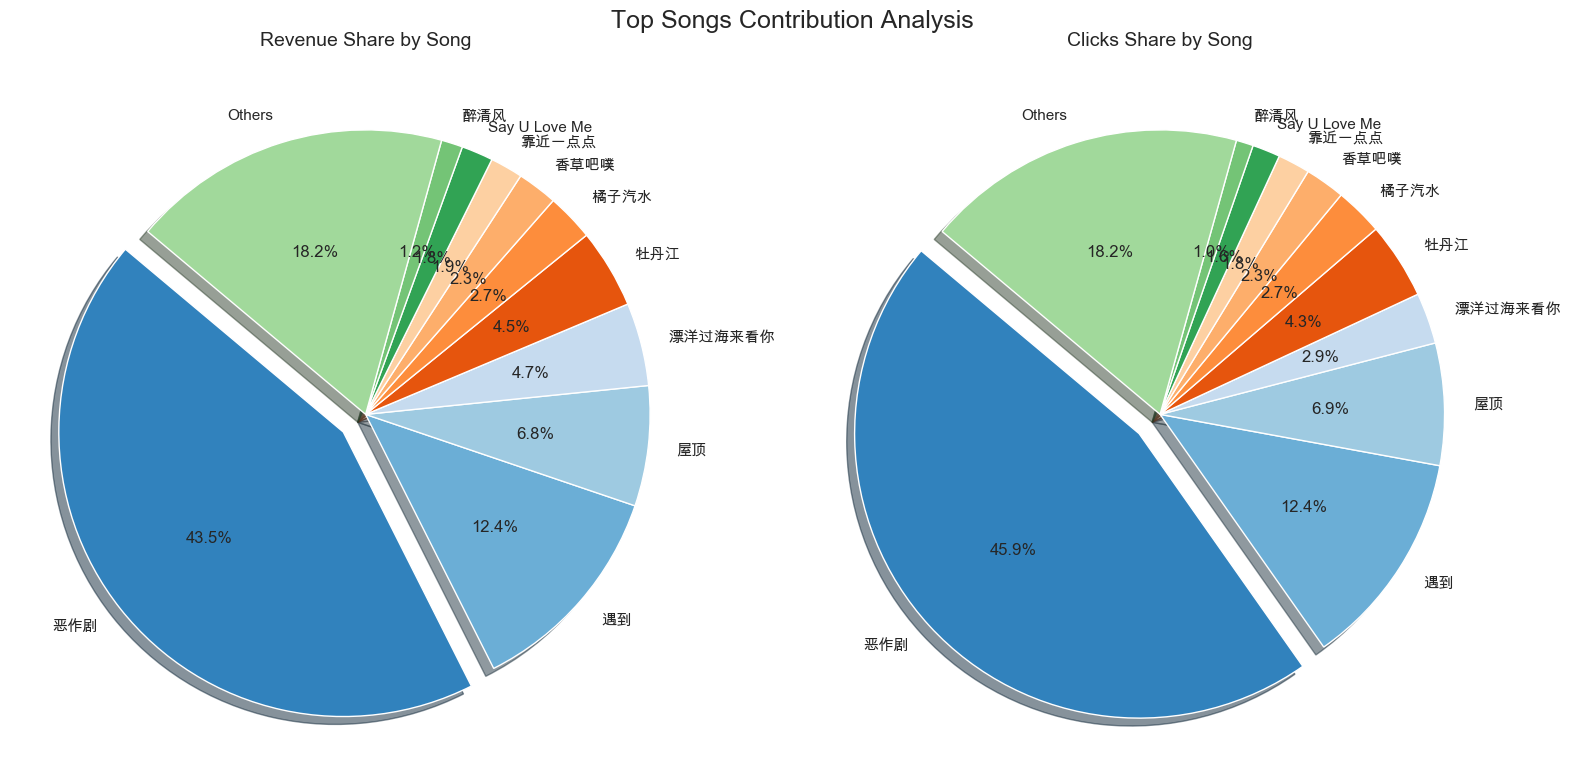

In [26]:
total_rev = revenue_by_song['revenue'].sum()
total_clicks = revenue_by_song['clicks'].sum()

revenue_by_song_top = revenue_by_song.head(TOP_N_SONGS).copy()
revenue_by_song_top['rev_share'] = revenue_by_song_top['revenue'] / total_rev
revenue_by_song_top['click_share'] = revenue_by_song_top['clicks'] / total_clicks
top_song_list = revenue_by_song_top['ISRC'].tolist()

print(f"Top {TOP_N_SONGS} songs contribute to {revenue_by_song_top['rev_share'].sum():.2%} of total revenue.")
display(revenue_by_song_top)

# Side-by-side pie charts for revenue & clicks contribution
top_song_detail = revenue_by_song.head(TOP_N_SONGS).copy()[['song', 'revenue', 'clicks']]
other_songs_rev = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['revenue'].sum()
other_songs_clicks = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['clicks'].sum()

others_row = pd.DataFrame([{
    'song': 'Others',
    'revenue': other_songs_rev,
    'clicks': other_songs_clicks
}])

df_pie = pd.concat([top_song_detail, others_row], ignore_index=True)
plotting.plot_pie_charts(df_pie)

## Generate Song Report
Aggregates, pivots, and exports monthly metrics to Excel.

In [27]:
song_final = generate_song_report(df_filtered, OUTPUT_SONG_REPORT_PATH_MONTHLY)

Song report exported successfully to: ../output/TME_Song_Report_Monthly_for_Sony_大曲庫.xlsx


In [28]:
song_final.head()

,ISRC,song,artist,UPC,album,total_click,total_revenue,2023-01_clicks,2023-01_revenue,2023-02_clicks,...,2025-08_clicks,2025-08_revenue,2025-09_clicks,2025-09_revenue,2025-10_clicks,2025-10_revenue,2025-11_clicks,2025-11_revenue,2025-12_clicks,2025-12_revenue
0,TWC230515112,恶作剧,王蓝茵,UPC-828767536125,恶作剧之吻 电视剧原声带,948810625.0,4.162906e+06,15577512.0,66101.000420,13585073.0,...,19551085.0,92520.505206,16911594.0,87563.060316,17755431.0,92547.295120,16920393.0,83858.981614,17712746.0,82249.244169
1,TWC230515103,遇到,方雅贤,UPC-828767536125,恶作剧之吻 电视剧原声带,255544347.0,1.181709e+06,7138515.0,28689.629770,7510041.0,...,6571331.0,30612.444688,5837432.0,30271.158690,5924374.0,30373.683705,5511271.0,27406.163085,5858819.0,27297.963643
2,TWC230107211,屋顶,"温岚,周杰伦",UPC-4710635380335,爱回温,143386080.0,6.526231e+05,3472910.0,16481.733303,3178422.0,...,4143723.0,16510.949614,3965474.0,17809.686885,4171578.0,18400.078671,3854632.0,16165.251385,3788060.0,15529.051369
3,TWI431603105,漂洋过海来看你,刘明湘,UPC-4712505300245,我不要再比了,59986962.0,4.512946e+05,0.0,0.000000,0.0,...,5120422.0,37735.712816,4843138.0,38841.180025,5586138.0,44015.840637,5349439.0,40290.560442,5532760.0,40257.166800
4,TWC230514205,牡丹江,南拳妈妈,UPC-828767296425,2号餐,89964991.0,4.310230e+05,1885826.0,8846.901922,2907614.0,...,2476783.0,12432.215776,2331140.0,12291.221615,2308601.0,12588.103736,2326935.0,11380.736975,2287652.0,11222.404234


## Generate Song Report by Year

In [29]:
df_filtered.head()

,Platform,YearMonth,Album,Song,Artist,UPC,ISRC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
2143259,Wesing,2023-01,挚爱,冷风过境,5566,NaN,TWA770300194,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,冷风过境,5566
2138657,KugouKaraoke,2023-01,空,跳支舞吧,彭文江,NaN,跳支舞吧 - 彭文江,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,跳支舞吧,彭文江
2138658,KugouKaraoke,2023-01,空,复杂情节,彭文江,NaN,复杂情节 - 彭文江,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,复杂情节,彭文江
2138659,KugouKaraoke,2023-01,空,晴天雨天,彭文江,NaN,晴天雨天 - 彭文江,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,晴天雨天,彭文江
2138660,KugouKaraoke,2023-01,空,包围我,彭文江,NaN,包围我 - 彭文江,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,包围我,彭文江


In [30]:
song_final = generate_song_report_by_year(df_filtered, OUTPUT_SONG_REPORT_PATH)
song_final.head()

Yearly song report exported successfully to: ../output/TME_Song_Report_for_Sony_大曲库.xlsx


,ISRC,song,artist,total_click,total_revenue,2023_clicks,2024_clicks,2025_clicks,2023_revenue,2024_revenue,2025_revenue
0,TWC230515112,恶作剧,王蓝茵,948810625.0,4.162906e+06,482431726.0,243939113.0,222439786.0,1.657627e+06,1.420051e+06,1.085227e+06
1,TWC230814104,下雨天,南拳妈妈,386491232.0,2.007223e+06,117752304.0,133845245.0,134893683.0,4.561341e+05,7.588172e+05,7.922722e+05
2,夏天的风 - 温岚,夏天的风,温岚,272103111.0,1.321365e+06,98466144.0,78539618.0,95097349.0,3.723631e+05,4.476324e+05,5.013694e+05
3,TWF710700026,同手同脚,温岚,181166850.0,1.197971e+06,8833065.0,10336639.0,161997146.0,3.428992e+04,5.700604e+04,1.106675e+06
4,爱的魔法 - 金莎,爱的魔法,金莎,233128085.0,1.181980e+06,96302216.0,66281933.0,70543936.0,3.970978e+05,4.360828e+05,3.487995e+05


## Monthly Revenue Trend for Top Songs

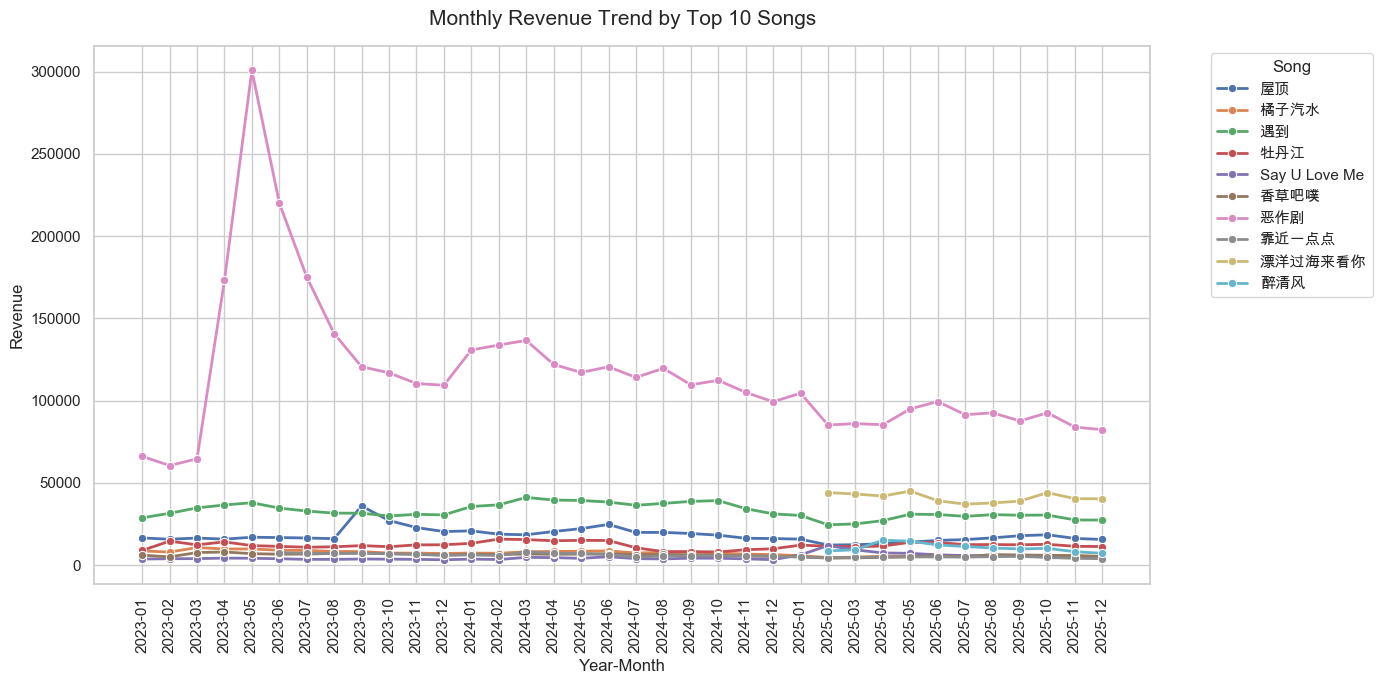

In [31]:
revenue_by_song_per_month = (
    df_filtered
    .groupby(['UPC', 'ISRC', 'YearMonth'])
    .agg(
        song=('standard_song', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
monthly_revenue_top_song = revenue_by_song_per_month[
    revenue_by_song_per_month['ISRC'].isin(top_song_list)
].sort_values('YearMonth')

plotting.plot_monthly_revenue_by_top_songs(monthly_revenue_top_song, TOP_N_SONGS)

## Revenue by Platform

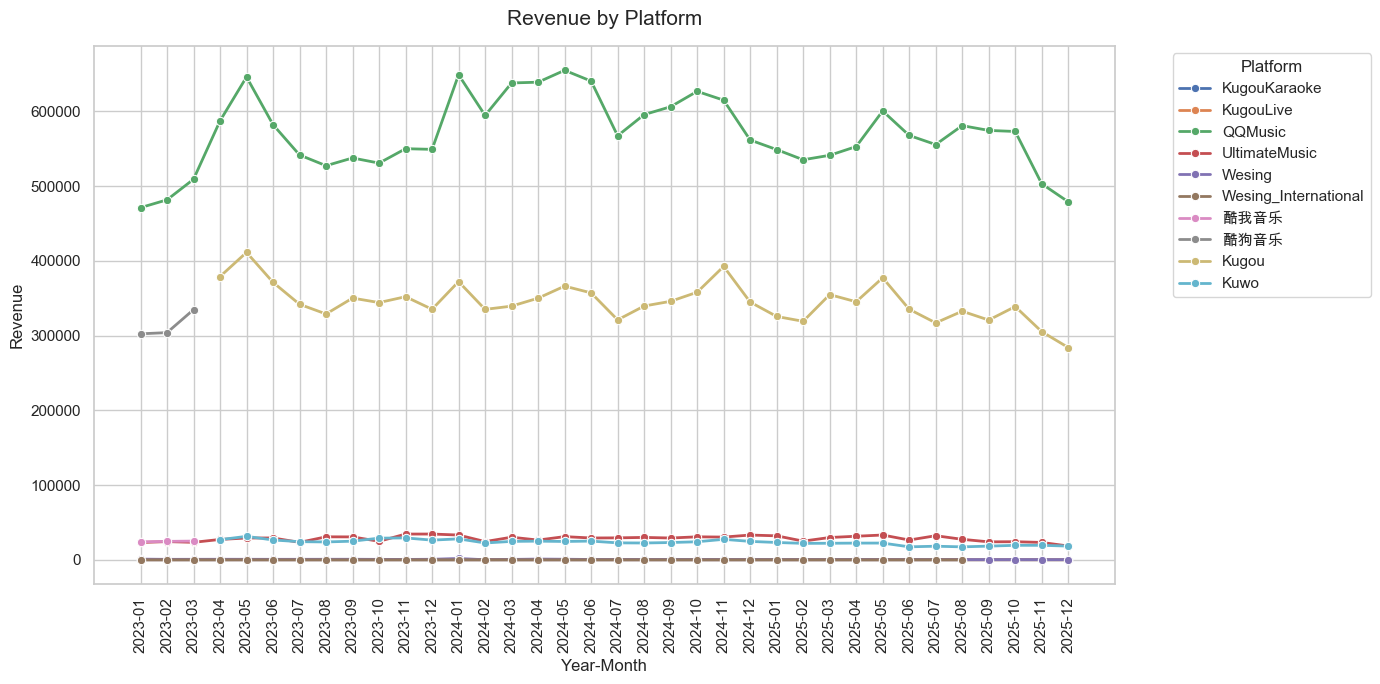

In [33]:
revenue_by_platform_per_month = (
    df_filtered
    .groupby(['ISRC', 'YearMonth', 'Platform'])
    .agg(revenue=('Revenue', 'sum'))
    .reset_index()
)
revenue_by_platform = (
    revenue_by_platform_per_month
    .groupby(['YearMonth', 'Platform'])
    .agg(revenue=('revenue', 'sum'))
    .reset_index()
)

plotting.plot_revenue_by_platform(revenue_by_platform)

In [34]:
revenue_by_platform['Platform'].value_counts()

Platform
KugouKaraoke            36
KugouLive               36
QQMusic                 36
UltimateMusic           36
Wesing                  36
Kugou                   33
Kuwo                    33
Wesing_International    32
酷我音乐                     3
酷狗音乐                     3
Name: count, dtype: int64

## Generate Album Report & Plot Revenue by Album

Top 10 albums contribute to 93.52% of total revenue.


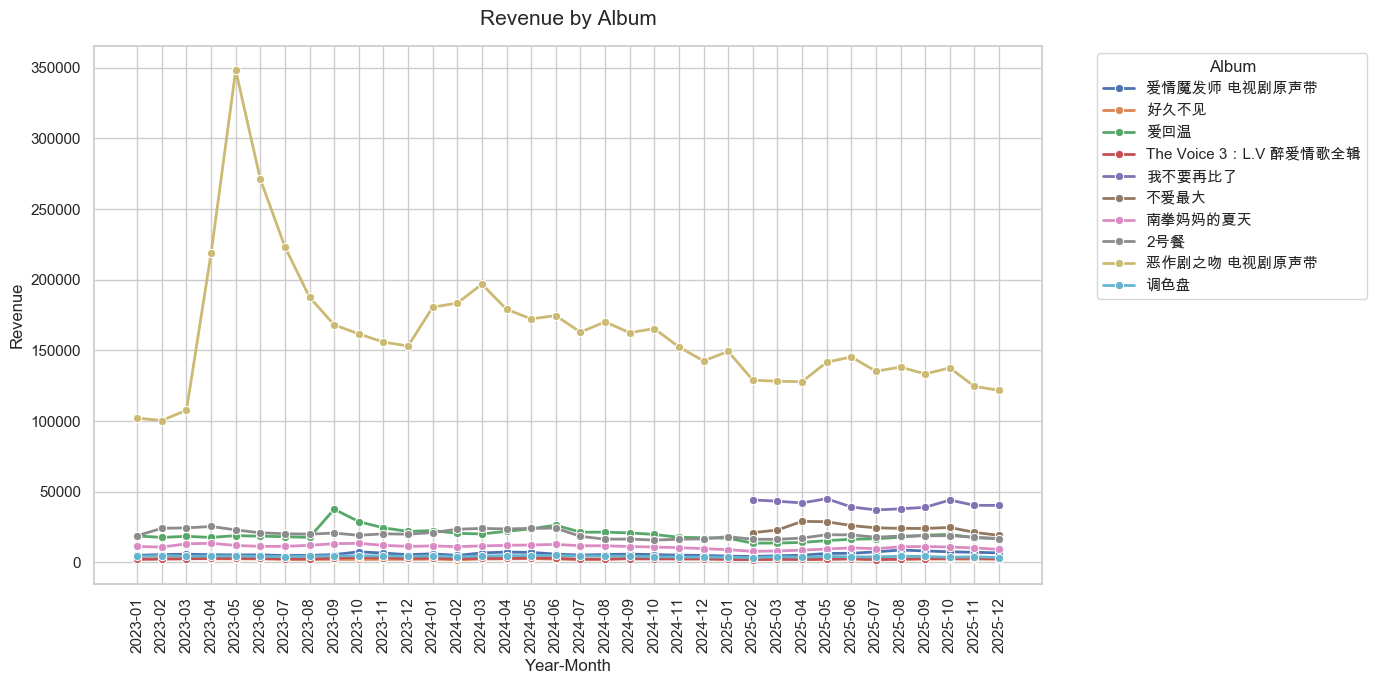

In [35]:
# Generate Excel report for Albums
# album_final = generate_album_report(df_filtered, OUTPUT_ALBUM_REPORT_PATH)
# display(album_final.head())

# Find top albums contribute to total revenue
revenue_by_album = (
    df_filtered
    .groupby(['UPC'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
revenue_by_album = revenue_by_album.sort_values('revenue', ascending=False)
print(f"Top {TOP_N_ALBUMS} albums contribute to {revenue_by_album['revenue'].head(TOP_N_ALBUMS).sum()/revenue_by_album['revenue'].sum():.2%} of total revenue.")

# Plot monthly trend lines for the top albums
top_n_album_list = revenue_by_album['UPC'].head(TOP_N_ALBUMS).tolist()
revenue_by_album_per_month = (
    df_filtered
    .groupby(['UPC', 'YearMonth'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
top_album_trend = revenue_by_album_per_month[
    revenue_by_album_per_month['UPC'].isin(top_n_album_list)
]
plotting.plot_revenue_by_album(top_album_trend)